# Research 06 — Weighted MaxCut across IBM, IQM, and Fujitsu OpenQARP
**Carlos Araque · Caraquel / KentryOps Data Labs · Portfolio research notebook**

Can a single optimization circuit retain its solution quality when implemented
in different frameworks and compiled for different device models?

We model a **synthetic task-conflict network**: an edge weight represents the
benefit of putting two tasks in different groups. Weighted MaxCut maximizes that
benefit. Five vertices keep the exact answer accessible and fit the local IBM
Manila and IQM Adonis models. This is a reproducible engineering case study, not
a claim of commercial scale or quantum advantage.

**Workflow:** classical solutions → train QAOA → freeze angles → verify circuit
equivalence → compare local simulators → optionally evaluate real hardware →
export results. Start with tutorials 00–05 if blocks, primitives, and engines
are new to you.

| Track | What actually runs | Purpose |
| --- | --- | --- |
| Classical exact + local search | Python/NumPy on CPU | Optimum and practical heuristic baseline |
| Aer ideal | Qiskit circuit on a local statevector simulator | Ideal sampled reference |
| Qrisp → Aer ideal | Qrisp circuit exported to Qiskit, executed by Aer | Portability check, not an independent simulator kernel |
| OpenQARP ideal | Fujitsu's local QarpEngine | Independent implementation of the same circuit |
| IBM Manila model | Local Aer with a bundled IBM noise snapshot | Routing and modeled noise impact |
| IQM Adonis model | IQMFakeAdonis target and noise model on seeded Aer | IQM native compilation and representative noise |
| IBM / IQM hardware | Optional remote QPU jobs | Real-device evaluation of frozen parameters |

Run all cells on a **fresh Colab CPU runtime with Python 3.11–3.13**. All cloud
connection and submission switches start off. No credentials are needed for the
local experiment. Default research size: 5 qubits, depth p=1, 3 optimizer starts,
5 sampling seeds, 2,048 shots per run.


## 1. Reproducible installation

IQM's current Qiskit integration and the latest IBM Runtime have conflicting
requirements. These direct dependency pins form a shared compatibility profile;
the exported environment records the complete resolved versions. Use the
maintained `iqm-client[qiskit]` integration rather than the old `qiskit-iqm`
distribution. Qrisp is used to construct a circuit, not merely imported.

Run installation once. If any of these packages were already imported, restart
the Colab session after installation, then continue at section 2. A full Colab
environment may contain unrelated preinstalled packages; the notebook checks
its direct versions and exports `pip check` output for diagnosis.


In [4]:
import sys, subprocess
assert (3, 11) <= sys.version_info[:2] < (3, 14), "Choose a Python 3.11–3.13 runtime."
PACKAGES = [
    "qiskit==2.1.2", "qiskit-aer==0.17.2", "qiskit-ibm-runtime==0.41.1",
    "iqm-client[qiskit,qrisp]==35.0.3", "qrisp==0.9.9", "openqarp==0.1.0",
    "numpy==2.3.5", "scipy==1.17.0", "pandas==2.3.3",
    "matplotlib==3.10.8", "networkx==3.5", "sympy==1.13.0", "scipy-stubs==1.17.0.0",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *PACKAGES])
print("Installation complete. Restart the session if packages were already imported.")


Installation complete. Restart the session if packages were already imported.


## 2. Configuration and experiment identity

All outcome labels inside this notebook are **q0-first**, e.g. `10000` means
qubit 0 is one. Qiskit count strings are reversed at the boundary. OpenQARP
tuple entries are already indexed by qubit. A circuit's measurements map logical
qubit q into classical bit q before transpilation, preserving logical output order.

Change the configuration, then rerun from here. The experiment hash includes
the problem, budgets, and seeds; each execution creates a separate output folder.


In [1]:
import os, sys, json, time, hashlib, platform, subprocess
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version, distributions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize
from scipy.stats import t as student_t
from IPython.display import display
from qiskit import QuantumCircuit, transpile, qasm3
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from iqm.qiskit_iqm import IQMFakeAdonis, transpile_to_IQM
from qarp.blocks import SimpleBlock
from qarp.algorithms import Sampler, StateVector
from qarp.engines import QarpEngine
from qarp.operators import QubitOperator
from qrisp import QuantumVariable, h as qr_h, cx as qr_cx, rz as qr_rz, rx as qr_rx

EXPECTED = {"qiskit": "2.1.2", "qiskit-aer": "0.17.2", "qiskit-ibm-runtime": "0.41.1",
            "iqm-client": "35.0.3", "qrisp": "0.9.9", "openqarp": "0.1.0",
            "numpy": "2.3.5", "scipy": "1.17.0", "pandas": "2.3.3",
            "matplotlib": "3.10.8", "networkx": "3.5", "sympy": "1.13.0", "scipy-stubs": "1.17.0.0"}
for package, expected in EXPECTED.items():
    assert version(package) == expected, f"Install the pinned version of {package}, then restart."

N = 5
EDGES = [(0, 1, 2.0), (1, 2, 1.0), (2, 3, 3.0), (3, 4, 2.0),
         (4, 0, 1.0), (0, 2, 2.0), (1, 4, 1.0)]
P = 1
SHOTS = 2048
SAMPLE_SEEDS = [11, 23, 37, 53, 71]
TRAIN_SEEDS = [7, 19, 41]
MAXITER = 120
TRANSPILE_SEED = 2026
assert 2 <= N <= 5, "Bundled five-qubit noise models limit this profile to N <= 5."
assert 1 <= P <= 3 and SHOTS >= 32 and len(SAMPLE_SEEDS) >= 2
assert len(set(SAMPLE_SEEDS)) == len(SAMPLE_SEEDS) and 0 not in SAMPLE_SEEDS
assert all(0 <= u < N and 0 <= v < N and u != v and w > 0 for u, v, w in EDGES)
assert len({tuple(sorted((u, v))) for u, v, _ in EDGES}) == len(EDGES)
CONFIG = dict(n=N, edges=EDGES, p=P, shots=SHOTS, sample_seeds=SAMPLE_SEEDS,
              train_seeds=TRAIN_SEEDS, maxiter=MAXITER, transpile_seed=TRANSPILE_SEED)
EXPERIMENT_ID = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:12]
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = Path("benchmark_results") / f"{EXPERIMENT_ID}_{RUN_ID}"
OUT.mkdir(parents=True, exist_ok=False)
print("Experiment:", EXPERIMENT_ID, "| outputs:", OUT)
display(pd.DataFrame([{"package": k, "version": version(k)} for k in EXPECTED]))


Experiment: 398931fcc280 | outputs: benchmark_results/398931fcc280_20260920T075046640721Z


,package,version
0,qiskit,2.1.2
1,qiskit-aer,0.17.2
2,qiskit-ibm-runtime,0.41.1
3,iqm-client,35.0.3
4,qrisp,0.9.9
5,openqarp,0.1.0
6,numpy,2.3.5
7,scipy,1.17.0
8,pandas,2.3.3
9,matplotlib,3.10.8


## 3. Solve the problem classically first

For assignment $x\in\{0,1\}^n$, $C(x)=\sum_{(u,v)}w_{uv}(x_u\oplus x_v)$.
Exhaustive enumeration evaluates all $2^n$ partitions and certifies the optimum.
Complementary assignments describe the same cut. The heuristic starts randomly
and repeatedly takes the best improving single-bit flip until no improvement
remains. Neither baseline is a simulator.

The exact timing includes enumeration and scoring. Heuristic timing includes its
search and objective evaluations. Later simulator timings execute an already
trained circuit, so comparing these times does **not** measure quantum speedup.


Exact optimum: 10.0 | optimal assignments: ['10010', '11010', '00101', '01101']
Enumeration wall time (seconds): 0.0031299039992518374


,seed,cut,approximation_ratio,assignment,evaluations,seconds
0,11,10.0,1.0,00101,6,0.000676
1,23,10.0,1.0,11010,11,0.000758
2,37,10.0,1.0,11010,16,0.000973
3,53,10.0,1.0,00101,16,0.000951
4,71,10.0,1.0,10010,11,0.000681


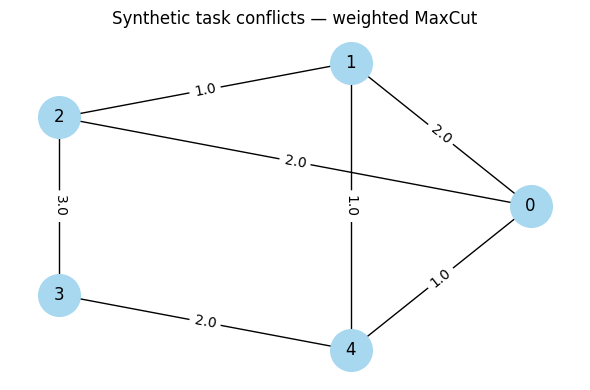

In [2]:
def cut_value(bits):
    return sum(w * (bits[u] != bits[v]) for u, v, w in EDGES)

t0 = time.perf_counter()
BASIS = ((np.arange(2**N)[:, None] >> np.arange(N)) & 1).astype(int)
LABELS = ["".join(map(str, bits)) for bits in BASIS]
COSTS = np.array([cut_value(bits) for bits in BASIS], dtype=float)
OPTIMUM = float(COSTS.max())
OPTIMAL = np.isclose(COSTS, OPTIMUM)
ENUMERATION_SECONDS = time.perf_counter() - t0
assert OPTIMUM > 0

def local_search(seed):
    start = time.perf_counter()
    bits = np.random.default_rng(seed).integers(0, 2, size=N)
    value, evaluations = cut_value(bits), 1
    while True:
        candidates = []
        for q in range(N):
            trial = bits.copy(); trial[q] ^= 1
            candidates.append((cut_value(trial), trial))
        evaluations += N
        new_value, new_bits = max(candidates, key=lambda pair: pair[0])
        if new_value <= value + 1e-12:
            break
        value, bits = new_value, new_bits
    return dict(seed=seed, cut=value, approximation_ratio=value / OPTIMUM,
                assignment="".join(map(str, bits)), evaluations=evaluations,
                seconds=time.perf_counter() - start)

CLASSICAL = pd.DataFrame([local_search(seed) for seed in SAMPLE_SEEDS])
print("Exact optimum:", OPTIMUM, "| optimal assignments:", [LABELS[i] for i in np.flatnonzero(OPTIMAL)])
print("Enumeration wall time (seconds):", ENUMERATION_SECONDS)
display(CLASSICAL)
G = nx.Graph(); G.add_nodes_from(range(N)); G.add_weighted_edges_from(EDGES)
fig, ax = plt.subplots(figsize=(6, 4))
pos = nx.circular_layout(G)
nx.draw_networkx(G, pos, ax=ax, node_color="#a7d8f0", node_size=900)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"), ax=ax)
ax.set_title("Synthetic task conflicts — weighted MaxCut"); ax.axis("off")
fig.tight_layout(); fig.savefig(OUT / "problem.png", dpi=160); plt.show()


## 4. Train once using an independent NumPy QAOA reference

Use $|+\rangle^{\otimes n}$, followed by p layers of
$e^{-i\beta_l\sum X_q}e^{-i\gamma_l C}$.
Since $C=\sum w(I-Z_uZ_v)/2$, each cost edge is implemented, up to global phase,
by CX–RZ(**−γw**)–CX, and each mixer by RX(**2β**).
Angles are stored as `[gamma_0, ..., gamma_(p-1), beta_0, ..., beta_(p-1)]`.
OpenQARP rotation methods take **(qubit, angle)**; Qiskit takes **(angle, qubit)**.

Three classical optimizer starts receive equal evaluation budgets. The best
observed expected cut selects the frozen angles, regardless of the optimizer's
termination flag; that flag is still recorded. Training is exact and noiseless,
so this studies **parameter transfer**, not on-device optimization. The exact
solver and the NumPy statevector both scale exponentially and are small-instance
research tools.


,seed,final_expected_cut,success,message,nfev,seconds
0,7,7.005916,True,Return from COBYLA because the trust region ra...,53,0.087723
1,19,6.743980,True,Return from COBYLA because the trust region ra...,61,0.086790
2,41,8.346997,True,Return from COBYLA because the trust region ra...,53,0.072803


Frozen angles: [5.94707771 1.20662434]
Ideal expected cut: 8.34699707755797 | optimum: 10.0


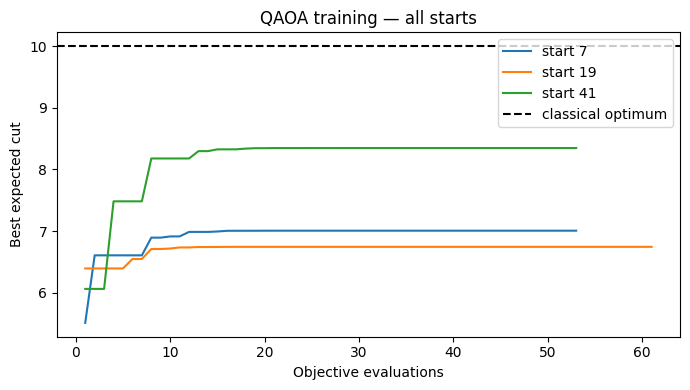

In [3]:
def numpy_probabilities(theta):
    theta = np.asarray(theta, dtype=float)
    assert theta.shape == (2 * P,)
    state = np.ones(2**N, dtype=complex) / np.sqrt(2**N)
    indices = np.arange(2**N)
    for layer in range(P):
        state *= np.exp(-1j * theta[layer] * COSTS)
        beta = theta[P + layer]
        for q in range(N):
            state = np.cos(beta) * state - 1j * np.sin(beta) * state[indices ^ (1 << q)]
    probs = np.abs(state)**2
    assert np.isclose(probs.sum(), 1.0)
    return probs

HISTORY, TRAINING = [], []
for seed in TRAIN_SEEDS:
    rng = np.random.default_rng(seed)
    x0 = np.r_[rng.uniform(0, 2*np.pi, P), rng.uniform(0, np.pi, P)]
    start = time.perf_counter()
    def objective(theta):
        expected = float(numpy_probabilities(theta) @ COSTS)
        HISTORY.append(dict(seed=seed, evaluation=sum(r['seed'] == seed for r in HISTORY) + 1,
                            expected_cut=expected, theta=np.asarray(theta).tolist()))
        return -expected
    result = minimize(objective, x0, method="COBYLA", options={"maxiter": MAXITER, "tol": 1e-6})
    TRAINING.append(dict(seed=seed, final_expected_cut=-float(result.fun),
                         success=bool(result.success), message=str(result.message),
                         nfev=int(result.nfev), seconds=time.perf_counter()-start))
best = max(HISTORY, key=lambda row: row['expected_cut'])
THETA = np.array(best['theta'])
IDEAL = numpy_probabilities(THETA)
TRAINING_SECONDS = sum(r['seconds'] for r in TRAINING)
display(pd.DataFrame(TRAINING))
print("Frozen angles:", THETA)
print("Ideal expected cut:", float(IDEAL @ COSTS), "| optimum:", OPTIMUM)
fig, ax = plt.subplots(figsize=(7, 4))
for seed in TRAIN_SEEDS:
    trace = [r for r in HISTORY if r['seed'] == seed]
    ax.plot([r['evaluation'] for r in trace], np.maximum.accumulate([r['expected_cut'] for r in trace]), label=f"start {seed}")
ax.axhline(OPTIMUM, color="black", linestyle="--", label="classical optimum")
ax.set(xlabel="Objective evaluations", ylabel="Best expected cut", title="QAOA training — all starts")
ax.legend(); fig.tight_layout(); fig.savefig(OUT / "training.png", dpi=160); plt.show()


## 5. Implement the identical circuit three ways

Qrisp builds its own program, then exports to Qiskit for execution. OpenQARP uses
its own block and engine. Independent gate construction catches parameter-order
and sign mistakes instead of assuming equivalent APIs.


In [4]:
def qiskit_circuit(theta, measured=False):
    qc = QuantumCircuit(N)
    qc.h(range(N))
    for layer in range(P):
        for u, v, w in EDGES:
            qc.cx(u, v); qc.rz(-float(theta[layer])*w, v); qc.cx(u, v)
        for q in range(N):
            qc.rx(2*float(theta[P + layer]), q)
    if measured:
        qc.measure_all()
    return qc

def qrisp_circuit(theta, measured=False):
    qv = QuantumVariable(N)
    for q in range(N):
        qr_h(qv[q])
    for layer in range(P):
        for u, v, w in EDGES:
            qr_cx(qv[u], qv[v]); qr_rz(-float(theta[layer])*w, qv[v]); qr_cx(qv[u], qv[v])
        for q in range(N):
            qr_rx(2*float(theta[P + layer]), qv[q])
    qc = qv.qs.compile().to_qiskit()
    assert qc.num_qubits == N
    if measured:
        qc.measure_all()
    return qc

def qarp_block(theta, measured=False):
    block = SimpleBlock(N, name="weighted_maxcut")
    for q in range(N):
        block.h(q)
    for layer in range(P):
        for u, v, w in EDGES:
            block.cx(u, v); block.rz(v, -float(theta[layer])*w); block.cx(u, v)
        for q in range(N):
            block.rx(q, 2*float(theta[P + layer]))
    if measured:
        block.measure([(q, q) for q in range(N)])
    block.build()
    return block

C_OPERATOR = QubitOperator()
for u, v, w in EDGES:
    C_OPERATOR += (w/2) * QubitOperator("") - (w/2) * QubitOperator(f"Z{u} Z{v}")

def qarp_expectation(theta):
    estimator = StateVector(ket=qarp_block(theta), operator=C_OPERATOR)
    engine = QarpEngine(seed=0)
    engine.build([estimator])
    return float(np.real(engine.run()[0]))

def compile_for_backend(source, backend, iqm=False):
    if iqm:
        assert 'move' not in backend.operation_names, "This profile supports direct-coupling IQM devices, not resonator/MOVE devices."
        # Explicitly bypass the MOVE-routing stage on architectures without resonators.
        return transpile_to_IQM(source, backend=backend, optimization_level=1,
                                seed_transpiler=TRANSPILE_SEED, perform_move_routing=False,
                                optimize_single_qubits=True)
    return transpile(source, backend=backend, optimization_level=1, seed_transpiler=TRANSPILE_SEED)

def counts_vector(counts):
    out = np.zeros(2**N, dtype=np.int64)
    for key, count in counts.items():
        compact = str(key).replace(" ", "")
        assert len(compact) == N and set(compact) <= {"0", "1"}
        assert int(count) == count and count >= 0
        out[int(compact, 2)] += int(count)
    return out

def qarp_counts(distribution, shots):
    probs = np.zeros(2**N)
    for bits, probability in distribution.items():
        assert len(bits) == N and all(int(b) in (0, 1) for b in bits)
        idx = sum(int(bit) << q for q, bit in enumerate(bits))
        probs[idx] += float(probability)
    assert np.isclose(probs.sum(), 1.0) and np.all(probs >= 0)
    counts = np.rint(probs * shots).astype(np.int64)
    assert counts.sum() == shots and np.allclose(counts / shots, probs, atol=1e-10)
    return counts

# Multiple non-optimal parameter vectors prevent a lucky agreement at one point.
CHECKS = []
for theta in [np.zeros(2*P), THETA, np.linspace(0.13, 0.79, 2*P), np.linspace(-0.6, 0.4, 2*P)]:
    reference = numpy_probabilities(theta)
    a = Statevector.from_instruction(qiskit_circuit(theta)).probabilities()
    b = Statevector.from_instruction(qrisp_circuit(theta)).probabilities()
    expected = float(reference @ COSTS)
    error = abs(qarp_expectation(theta) - expected)
    assert np.allclose(a, reference, atol=1e-9)
    assert np.allclose(b, reference, atol=1e-9)
    assert error < 1e-8
    CHECKS.append(dict(qiskit_max_error=float(abs(a-reference).max()),
                       qrisp_max_error=float(abs(b-reference).max()), qarp_cost_error=error))

# Asymmetric basis tests: detect reversal that a Bell-state test would miss.
for q in range(N):
    assert counts_vector({format(1 << q, f"0{N}b"): 32})[1 << q] == 32
    block = SimpleBlock(N); block.x(q); block.measure([(j, j) for j in range(N)]); block.build()
    primitive = Sampler(ket=block, n_shots=32)
    engine = QarpEngine(seed=0); engine.build([primitive])
    assert qarp_counts(engine.run()[0], 32)[1 << q] == 32
display(pd.DataFrame(CHECKS))
print("Circuit equivalence, objective sign, and asymmetric bit-order checks passed.")


,qiskit_max_error,qrisp_max_error,qarp_cost_error
0,1.734723e-17,1.734723e-17,2.664535e-15
1,5.551115e-17,6.938894e-17,3.552714e-15
2,3.469447e-17,2.081668e-17,5.329071e-15
3,6.938894e-17,4.857226e-17,5.329071e-15


Circuit equivalence, objective sign, and asymmetric bit-order checks passed.


## 6. Repeated local benchmark

Every track uses the same frozen angles, problem, shot budget, seed list, and
transpiler seed. A warm-up is excluded from timed repetitions. Preparation time
covers circuit building and compilation; run time covers engine construction
where required, execution, and result retrieval. OpenQARP preparation is repeated
per seed and itemized separately; Aer circuits are compiled once and reused.
Do not interpret these different API timing boundaries as a kernel speed ranking.

IBM and IQM fake backends use **different noise models and architectures**. Their
scores demonstrate sensitivity to compilation and noise, not which vendor has
better current hardware. Qrisp→Aer and IQM's fake simulator also use Aer internally.
IQMFakeAdonis.run in the pinned release does not forward the simulator seed, so
we explicitly use its target and noise model with seeded Aer execution.
For this pinned stack, default IQM MOVE routing changed the ideal distribution
in a local regression check on Adonis. We explicitly disable MOVE routing for
direct-coupling IQM architectures and verify the compiled logical distribution
before sampling. Resonator/MOVE hardware needs a separate validated compilation
profile and is rejected here.
OpenQARP is evaluated ideally here; no equivalent Fujitsu hardware connection is
configured.

The mean-cut interval estimates shot uncertainty (normal approximation), and the
optimum-hit interval is Wilson's binomial interval. Repetition summaries report
Student-t intervals over seeds; these do not include calibration drift, model
error, optimizer variability, or uncertainty across different problem instances.


In [5]:
def wilson(hits, total):
    z = 1.959963984540054
    phat = hits / total
    denom = 1 + z*z/total
    center = (phat + z*z/(2*total))/denom
    radius = z*np.sqrt(phat*(1-phat)/total + z*z/(4*total*total))/denom
    return float(center-radius), float(center+radius)

def score_counts(counts):
    counts = np.asarray(counts, dtype=np.int64)
    total = int(counts.sum())
    assert total > 1 and counts.shape == (2**N,) and np.all(counts >= 0)
    probs = counts / total
    mean = float(probs @ COSTS)
    variance = float(counts @ ((COSTS-mean)**2) / (total-1))
    se = np.sqrt(variance / total)
    hits = int(counts[OPTIMAL].sum())
    lo, hi = wilson(hits, total)
    return dict(shots=total, expected_cut=mean, approximation_ratio=mean/OPTIMUM,
                mean_cut_ci_low=max(0.0, mean-1.96*se), mean_cut_ci_high=min(OPTIMUM, mean+1.96*se),
                optimum_probability=hits/total, optimum_ci_low=lo, optimum_ci_high=hi,
                best_observed_cut=float(COSTS[counts > 0].max()),
                tvd_to_ideal=float(0.5*abs(probs-IDEAL).sum()))

def circuit_stats(qc):
    return dict(depth=qc.depth(), two_qubit_gates=sum(len(inst.qubits)==2 and inst.operation.name != "barrier" for inst in qc.data),
                operations={str(k): int(v) for k, v in qc.count_ops().items()})

def compiled_logical_probabilities(qc):
    # Recover classical logical output order after routing/layout permutations.
    mapping = [(qc.find_bit(inst.qubits[0]).index, qc.find_bit(inst.clbits[0]).index)
               for inst in qc.data if inst.operation.name == 'measure']
    assert len(mapping) == N and {c for _, c in mapping} == set(range(N))
    physical = Statevector.from_instruction(qc.remove_final_measurements(inplace=False)).probabilities()
    logical = np.zeros(2**N)
    for index, probability in enumerate(physical):
        output = sum(((index >> q) & 1) << c for q, c in mapping)
        logical[output] += probability
    return logical

ROWS, RAW, COMPILED = [], [], {}
PREPARATION = []
iqm_model = IQMFakeAdonis()
tracks = [
    ("Aer ideal", "ideal", AerSimulator(method="statevector", max_parallel_threads=1), qiskit_circuit),
    ("Qrisp to Aer ideal", "ideal", AerSimulator(method="statevector", max_parallel_threads=1), qrisp_circuit),
    ("IBM Manila noise model", "device_model", AerSimulator.from_backend(FakeManilaV2(), method="density_matrix", max_parallel_threads=1), qiskit_circuit),
    ("IQM Adonis noise model", "device_model", AerSimulator(noise_model=iqm_model.noise_model, method="density_matrix", max_parallel_threads=1), qiskit_circuit),
]
for name, kind, backend, builder in tracks:
    start = time.perf_counter()
    source = builder(THETA, measured=True)
    target = iqm_model if name == "IQM Adonis noise model" else backend
    compiled = compile_for_backend(source, target, iqm=(name == "IQM Adonis noise model"))
    prep = time.perf_counter()-start
    stats = circuit_stats(compiled)
    assert np.allclose(compiled_logical_probabilities(compiled), IDEAL, atol=1e-8), name + ': routing changed the distribution'
    COMPILED[name] = compiled
    PREPARATION.append(dict(track=name, seed=None, seconds=prep, **stats))
    backend.run(compiled, shots=32, seed_simulator=0).result()  # untimed warm-up
    for seed in SAMPLE_SEEDS:
        start = time.perf_counter()
        result = backend.run(compiled, shots=SHOTS, seed_simulator=seed).result()
        counts = counts_vector(result.get_counts())
        elapsed = time.perf_counter()-start
        assert counts.sum() == SHOTS
        ROWS.append(dict(track=name, kind=kind, seed=seed, run_seconds=elapsed,
                         preparation_seconds=prep, depth=stats['depth'],
                         two_qubit_gates=stats['two_qubit_gates'], **score_counts(counts)))
        RAW.append(dict(track=name, seed=seed, counts=counts.tolist()))
    print("Completed:", name)

for seed in [0] + SAMPLE_SEEDS:
    shots = 32 if seed == 0 else SHOTS
    start = time.perf_counter()
    block = qarp_block(THETA, measured=True)
    primitive = Sampler(ket=block, n_shots=shots)
    engine = QarpEngine(seed=seed)
    engine.build([primitive])
    prep = time.perf_counter()-start
    start = time.perf_counter()
    counts = qarp_counts(engine.run()[0], shots)
    elapsed = time.perf_counter()-start
    if seed == 0:
        continue
    # Gate/depth statistics here describe the logical Qiskit equivalent, not QarpEngine's internal compilation.
    PREPARATION.append(dict(track="OpenQARP ideal", seed=seed, seconds=prep,
                            depth=None, two_qubit_gates=None, operations={}))
    ROWS.append(dict(track="OpenQARP ideal", kind="ideal", seed=seed, run_seconds=elapsed,
                     preparation_seconds=prep, depth=None, two_qubit_gates=None, **score_counts(counts)))
    RAW.append(dict(track="OpenQARP ideal", seed=seed, counts=counts.tolist()))

RESULTS = pd.DataFrame(ROWS)
display(RESULTS)


Completed: Aer ideal
Completed: Qrisp to Aer ideal
Completed: IBM Manila noise model
Completed: IQM Adonis noise model


,track,kind,seed,run_seconds,preparation_seconds,depth,two_qubit_gates,shots,expected_cut,approximation_ratio,mean_cut_ci_low,mean_cut_ci_high,optimum_probability,optimum_ci_low,optimum_ci_high,best_observed_cut,tvd_to_ideal
0,Aer ideal,ideal,11,0.005585,0.249007,21.0,14.0,2048,8.315430,0.831543,8.232626,8.398233,0.397461,0.376477,0.418828,10.0,0.040487
1,Aer ideal,ideal,23,0.005448,0.249007,21.0,14.0,2048,8.315430,0.831543,8.234541,8.396318,0.406738,0.385657,0.428168,10.0,0.048451
2,Aer ideal,ideal,37,0.005382,0.249007,21.0,14.0,2048,8.388672,0.838867,8.308841,8.468502,0.415527,0.394361,0.437010,10.0,0.049246
3,Aer ideal,ideal,53,0.005360,0.249007,21.0,14.0,2048,8.416504,0.841650,8.336027,8.496981,0.425781,0.404525,0.447315,10.0,0.038826
4,Aer ideal,ideal,71,0.005391,0.249007,21.0,14.0,2048,8.310059,0.831006,8.227711,8.392406,0.403809,0.382758,0.425220,10.0,0.055978
5,Qrisp to Aer ideal,ideal,11,0.007469,0.125715,21.0,14.0,2048,8.315430,0.831543,8.232626,8.398233,0.397461,0.376477,0.418828,10.0,0.040487
6,Qrisp to Aer ideal,ideal,23,0.006224,0.125715,21.0,14.0,2048,8.315430,0.831543,8.234541,8.396318,0.406738,0.385657,0.428168,10.0,0.048451
7,Qrisp to Aer ideal,ideal,37,0.005804,0.125715,21.0,14.0,2048,8.388672,0.838867,8.308841,8.468502,0.415527,0.394361,0.437010,10.0,0.049246
8,Qrisp to Aer ideal,ideal,53,0.006024,0.125715,21.0,14.0,2048,8.416504,0.841650,8.336027,8.496981,0.425781,0.404525,0.447315,10.0,0.038826
9,Qrisp to Aer ideal,ideal,71,0.005887,0.125715,21.0,14.0,2048,8.310059,0.831006,8.227711,8.392406,0.403809,0.382758,0.425220,10.0,0.055978


## 7. Compare quality, uncertainty, and observed latency

Uniform random partitions are an analytic baseline; local search returns one
assignment per seed; QAOA produces a distribution per seed. Compare their solution
quality, while keeping those sampling and computation budgets explicit.
The exact optimum is a ceiling. Finding an optimal bitstring at least once does
not mean a high expected cut or a reliable optimum-hit probability.


,track,repetitions,mean_ratio,ratio_ci_halfwidth,mean_optimum_probability,mean_tvd,median_run_seconds,median_preparation_seconds
0,Aer ideal,5,0.834922,0.006177,0.409863,0.046598,0.005391,0.249007
1,Qrisp to Aer ideal,5,0.834922,0.006177,0.409863,0.046598,0.006024,0.125715
2,IBM Manila noise model,5,0.774482,0.006435,0.311816,0.139214,0.078003,0.018611
3,IQM Adonis noise model,5,0.736318,0.003007,0.282129,0.224731,0.089486,0.017459
4,OpenQARP ideal,5,0.833721,0.006505,0.406836,0.033165,0.001456,0.000502


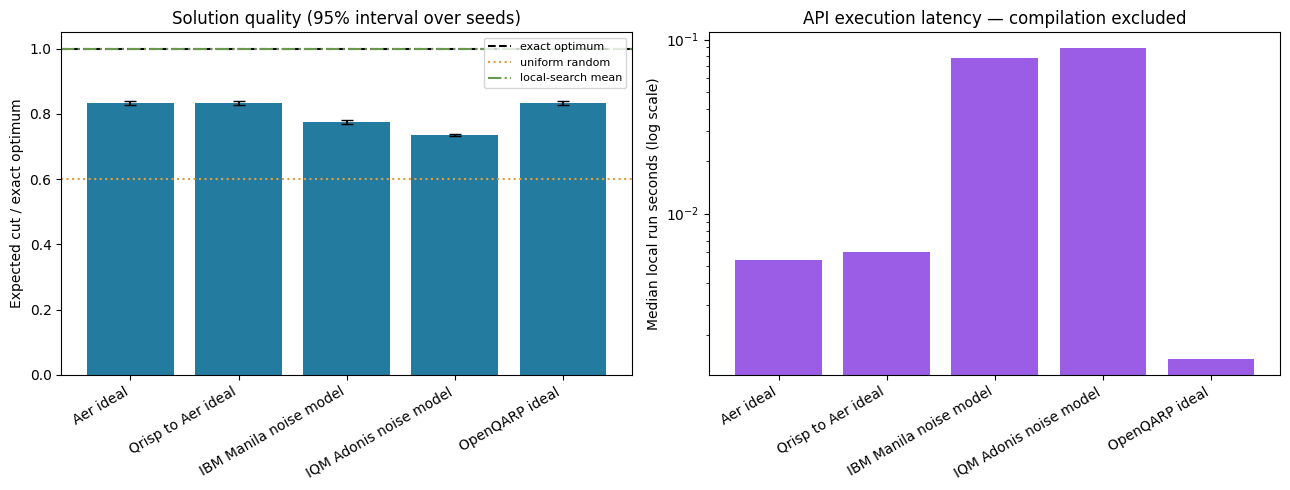

Shared QAOA training seconds: 0.24731546800012438
Full experimental cost also includes setup, correctness checks, compilation, and warm-up.


In [6]:
summary_rows = []
for name, group in RESULTS.groupby('track', sort=False):
    ratio = group.approximation_ratio
    halfwidth = float(student_t.ppf(0.975, len(group)-1) * ratio.std(ddof=1) / np.sqrt(len(group)))
    summary_rows.append(dict(track=name, repetitions=len(group), mean_ratio=ratio.mean(),
                             ratio_ci_halfwidth=halfwidth, mean_optimum_probability=group.optimum_probability.mean(),
                             mean_tvd=group.tvd_to_ideal.mean(), median_run_seconds=group.run_seconds.median(),
                             median_preparation_seconds=group.preparation_seconds.median()))
SUMMARY = pd.DataFrame(summary_rows)
display(SUMMARY)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(SUMMARY))
axes[0].bar(x, SUMMARY.mean_ratio, yerr=SUMMARY.ratio_ci_halfwidth, capsize=4, color="#247ba0")
axes[0].axhline(1, color="black", linestyle="--", label="exact optimum")
axes[0].axhline(float(COSTS.mean()/OPTIMUM), color="#e09f3e", linestyle=":", label="uniform random")
axes[0].axhline(CLASSICAL.approximation_ratio.mean(), color="#6a994e", linestyle="-.", label="local-search mean")
axes[0].set(ylabel="Expected cut / exact optimum", title="Solution quality (95% interval over seeds)")
axes[0].legend(fontsize=8)
axes[1].bar(x, SUMMARY.median_run_seconds, color="#9b5de5")
axes[1].set(yscale="log", ylabel="Median local run seconds (log scale)", title="API execution latency — compilation excluded")
for ax in axes:
    ax.set_xticks(x, SUMMARY.track, rotation=30, ha="right")
fig.tight_layout(); fig.savefig(OUT / "comparison.png", dpi=180); plt.show()
print("Shared QAOA training seconds:", TRAINING_SECONDS)
print("Full experimental cost also includes setup, correctness checks, compilation, and warm-up.")


## 8. Optional real hardware — reuse your existing connections

Run the shared setup once, then run **IBM or IQM independently**. Each connection
cell reads only its provider's credentials. Connecting does not submit a circuit.
The separate submission switches still default to off.

| Setting | Default Secret / environment name | Purpose |
| --- | --- | --- |
| IBM token / instance | IBM_TOKEN / IBM_CRN | Preferred credential pair from your validation example |
| IBM token / instance fallback | IBM_QUANTUM_TOKEN / IBM_QUANTUM_CRN | Earlier notebook's pair; never mix pairs |
| IBM backend | IBM_BACKEND | Explicit real device name from your account |
| IQM token | IQM_API_TOKEN | Existing IQM token |
| IQM server | IQM_SERVER_URL | Defaults to the documented IQM Resonance endpoint |
| IQM device | IQM_QUANTUM_COMPUTER | Defaults to garnet; select an entitled device |

Secrets are read only after enabling the relevant connection. Saved IBM accounts
are loaded without overwriting them unless `SAVE_IBM_ACCOUNT=True`. Keep backend names explicit; account access,
available devices, supported circuits, quotas, and possible charges depend on
your entitlements. A mock IQM endpoint produces random integration-test results
and must not be described as hardware.

1. Run 8A and grant this Colab notebook access to your Secrets.
2. Enable `CONNECT_IBM` in 8B or `CONNECT_IQM` in 8C; run that provider's cell.
3. For IBM, choose `IBM_BACKEND` from the printed list and rerun 8B. For IQM,
   run 8D to prepare the benchmark adapter. Review the circuit in 8F.
4. Enable the corresponding submission switch and run **only the submission cell**.
5. Retrieve results separately. A timeout must be followed by retrieval, not resubmission.

One job per provider contains one frozen circuit per repetition, each with the
same shot budget used locally. Hardware repetitions have no controllable RNG
seed; their variability includes shot noise and possibly device drift. They are
not synchronized across providers.

### 8A. Shared hardware settings — run once before the provider cells

Rerunning this setup resets the prepared benchmark circuits. Rerunning an IBM or
IQM cell afterward changes only that provider's entry. The on-disk job ledger is
preserved. **Do not use the account label as a Python keyword**: the SDK parameter
is `instance=your_crn`. `ibm_qgss2025_dkt_ca` is used below as an optional saved
account label; authentication uses the value of your CRN Secret.


In [10]:
# Shared hardware setup; connections are configured in their own cells below.
HARDWARE_SHOTS = SHOTS
HARDWARE_REPETITIONS = len(SAMPLE_SEEDS)
IBM_SECRET_PAIRS = [("IBM_TOKEN", "IBM_CRN"), ("IBM_QUANTUM_TOKEN", "IBM_QUANTUM_CRN")]
IQM_TOKEN_SECRET = "IQM_API_TOKEN"
# Reuse a ledger from an earlier session to retrieve jobs without submitting again.
LEDGER_PATH = Path("benchmark_results") / f"hardware_jobs_{EXPERIMENT_ID}.json"

def read_secret(key, required=False):
    value = os.environ.get(key)
    if not value:
        try:
            from google.colab import userdata
            value = userdata.get(key)
        except (ImportError, KeyError):
            pass
        except Exception:
            # Colab raises provider-specific exceptions for missing/denied secrets.
            value = None
    if required and not value:
        raise ValueError(f"Configure environment variable or Colab Secret: {key}")
    return value

def ibm_credentials():
    for token_name, crn_name in IBM_SECRET_PAIRS:
        token, crn = read_secret(token_name), read_secret(crn_name)
        if token or crn:
            if not (token and crn):
                raise ValueError(f"Provide both {token_name} and {crn_name}; credential pairs are not mixed.")
            return token, crn
    return None, None  # the IBM cell can reuse a saved account

HARDWARE = {}
print("Shared settings ready. Run the IBM and/or IQM connection cell next.")


Shared settings ready. Run the IBM and/or IQM connection cell next.


### 8B. IBM — authenticate, list devices, and prepare your chosen backend

This follows your validation example and accepts either complete IBM Secret pair.
Set `SAVE_IBM_ACCOUNT=True` only if you want to save/overwrite the named account
and make it the default. Direct connection works without saving credentials.
If no Secrets are supplied, an existing default saved account is loaded.

Set `IBM_BACKEND` to a name printed by the account check, then rerun this cell.
Leaving it blank performs account validation only; it does not choose a device
or submit a job. See [IBM account initialization](https://quantum.cloud.ibm.com/docs/en/guides/initialize-account).


In [15]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

# Retrieve credentials from Colab Secrets.
IBM_QUANTUM_TOKEN = userdata.get("IBM_QUANTUM_TOKEN")
IBM_CRN = userdata.get("IBM_QUANTUM_CRN")

if not IBM_QUANTUM_TOKEN or not IBM_CRN:
    raise ValueError(
        "Add IBM_QUANTUM_TOKEN and IBM_CRN to Colab Secrets before continuing."
    )

# Save the account for this Colab runtime and make it the default.
QiskitRuntimeService.save_account(
    token=IBM_QUANTUM_TOKEN,
    instance=IBM_CRN,
    overwrite=True,
    set_as_default=True,
)

service = QiskitRuntimeService()
print("✅ IBM Quantum account configured successfully")

✅ IBM Quantum account configured successfully


In [17]:
import pandas as pd

backend_data = []

# Fetch backends (filtering to operational, real hardware)
for b in service.backends(simulator=False, operational=True):
    status = b.status()
    backend_data.append(
        {
            "Name": b.name,
            "Qubits": b.num_qubits,
            "Pending Jobs": status.pending_jobs,
            "Status": status.status_msg,
        }
    )

# Create and display sorted table
df_backends = pd.DataFrame(backend_data).sort_values(by="Pending Jobs")
df_backends.reset_index(drop=True, inplace=True)
df_backends

,Name,Qubits,Pending Jobs,Status
0,ibm_fez,156,0,active
1,ibm_marrakesh,156,0,active
2,ibm_kingston,156,1,active


In [18]:
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

# --- Configuration ---
IBM_BACKEND = "ibm_marrakesh"  # Paste backend name here (or store in Colab Secrets as IBM_BACKEND)

HARDWARE.pop("IBM", None)

# 1. Authenticate using Colab Secrets
token = userdata.get("IBM_QUANTUM_TOKEN")
crn = userdata.get("IBM_QUANTUM_CRN")

if token and crn:
    QiskitRuntimeService.save_account(
        token=token,
        instance=crn,
        overwrite=True,
        set_as_default=True,
    )

service = QiskitRuntimeService()

# 2. List available backends
available_backends = service.backends()
print(f"✅ IBM account OK. {len(available_backends)} backend(s) available:")
for b in available_backends:
    print(f"  • {b.name} ({b.num_qubits} qubits)")

# 3. Select backend & prepare benchmark
backend_name = IBM_BACKEND or userdata.get("IBM_BACKEND")

if backend_name:
    backend = service.backend(backend_name)
    assert not backend.configuration().simulator, "Choose real IBM hardware."
    assert backend.num_qubits >= N, f"Backend needs at least {N} qubits."

    compiled = compile_for_backend(qiskit_circuit(THETA, True), backend)
    HARDWARE["IBM"] = dict(backend=backend, circuit=compiled)
    print(f"\n🚀 IBM benchmark prepared for '{backend_name}'. Review in 8F before submission.")
else:
    print("\n👉 Set IBM_BACKEND to one of the devices listed above and rerun this cell.")

✅ IBM account OK. 3 backend(s) available:
  • ibm_fez (156 qubits)
  • ibm_marrakesh (156 qubits)
  • ibm_kingston (156 qubits)

🚀 IBM benchmark prepared for 'ibm_marrakesh'. Review in 8F before submission.


### 8C. IQM — connect Qrisp using your existing token

This creates `quantum_computer`, as in your previous notebooks. The pinned Qrisp
package re-exports IQM's adapter, which needs the `qrisp` extra installed by
section 1. The current keyword is `token`; your older `api_token` spelling is
accepted as an alias in this version. A server URL is also supplied explicitly.
See the [IQM Qrisp guide](https://docs.iqm.tech/iqm-client/user_guide_qrisp/index.html).

Choose `garnet` or another device that your IQM account provides. You can select
`sirius` for the Qrisp connection/measurement example, subject to entitlement;
the MaxCut benchmark's validated adapter currently supports direct-coupling
devices and does not support Sirius's resonator/MOVE architecture.
Optional `IQM_QUANTUM_COMPUTER` and `IQM_SERVER_URL` Secrets override the
non-secret values in this cell; the token always comes from `IQM_API_TOKEN`.


In [20]:
# IQM Qrisp connection — independent of IBM.
CONNECT_IQM = True  # change to True to connect using IQM_API_TOKEN
IQM_DEVICE = "garnet"  # change to "sirius" for the separate Qrisp example, if entitled
IQM_SERVER_URL = "https://resonance.iqm.tech/"
EXISTING_IQM_QRISP_BACKEND = None  # previously configured Qrisp IQMBackend, if available

HARDWARE.pop('IQM', None)  # invalidate the earlier benchmark if you change devices
quantum_computer = None
if CONNECT_IQM:
    from qrisp.interface import IQMBackend
    iqm_device = read_secret("IQM_QUANTUM_COMPUTER") or IQM_DEVICE
    iqm_url = read_secret("IQM_SERVER_URL") or IQM_SERVER_URL
    assert all(word not in iqm_device.lower() for word in ['mock', 'fake', 'facade'])
    quantum_computer = EXISTING_IQM_QRISP_BACKEND
    if quantum_computer is None:
        quantum_computer = IQMBackend(token=read_secret(IQM_TOKEN_SECRET, required=True),
                                     device_instance=iqm_device, server_url=iqm_url)
    print("IQM Qrisp backend connected. No circuit has been submitted.")
else:
    print("IQM connection disabled. IBM can be configured independently.")


IQM Qrisp backend connected. No circuit has been submitted.


### 8D. IQM — prepare the tracked MaxCut benchmark

The benchmark submission cell expects a Qiskit backend and compiled Qiskit
circuits. It cannot use the Qrisp `quantum_computer` object directly. This cell
creates that separate adapter using the same IQM Secret and device configuration.
It preserves any IBM circuit already prepared in 8B. Changing `IQM_DEVICE`
requires rerunning 8C before this cell.


In [21]:
# IQM benchmark adapter — run after the IQM Qrisp connection cell.
PREPARE_IQM_BENCHMARK = True
EXISTING_IQM_BACKEND = None  # Qiskit IQMBackend only; not the Qrisp quantum_computer

HARDWARE.pop('IQM', None)
if CONNECT_IQM and PREPARE_IQM_BENCHMARK:
    assert quantum_computer is not None, "Run the IQM connection cell first."
    from iqm.qiskit_iqm import IQMProvider
    backend = EXISTING_IQM_BACKEND
    if backend is None:
        provider = IQMProvider(iqm_url, quantum_computer=iqm_device,
                               token=read_secret(IQM_TOKEN_SECRET, required=True))
        backend = provider.get_backend()
    assert backend.num_qubits >= N
    assert all(word not in backend.name.lower() for word in ['mock', 'fake', 'facade'])
    if 'move' in backend.operation_names:
        print("IQM Qrisp connection is available, but this resonator/MOVE device is outside the benchmark profile.")
        print("Use the separate Qrisp example or select an entitled direct-coupling device such as Garnet.")
    else:
        compiled = compile_for_backend(qiskit_circuit(THETA, True), backend, iqm=True)
        HARDWARE['IQM'] = dict(backend=backend, circuit=compiled)
        print("IQM benchmark prepared. Review it in 8F before submission.")
else:
    print("IQM benchmark preparation disabled.")


IQM benchmark prepared. Review it in 8F before submission.


### 8E. Optional Qrisp `plus` measurement — a separate hardware example

This implements your `plus.get_measurement(backend=quantum_computer)` example
with an explicit shot budget. Setting the switch below to True submits a new
hardware measurement each time this cell is run. It is a separate demonstration,
not part of the MaxCut results or its job ledger. It does not require IBM.


In [23]:
# Optional Qrisp hardware measurement; not needed for the benchmark.
RUN_IQM_QRISP_SMOKE_TEST = True
IQM_SMOKE_SHOTS = 128
if RUN_IQM_QRISP_SMOKE_TEST:
    assert CONNECT_IQM and quantum_computer is not None, "Run the IQM connection cell first."
    plus = QuantumVariable(1)
    qr_h(plus[0])
    plus_result = plus.get_measurement(backend=quantum_computer, shots=IQM_SMOKE_SHOTS)
    print("IQM |+> measurement:", plus_result)
else:
    print("Optional IQM Qrisp hardware measurement disabled.")


IQM |+> measurement: {'0': 0.5078125, '1': 0.4921875}


### 8F. Review prepared benchmark circuits

Only prepared providers appear here. IBM authentication alone (without a chosen
backend) and the separate Qrisp IQM connection do not create benchmark jobs.
Enable `SUBMIT_IBM` and/or `SUBMIT_IQM` in the following submission cell only for
providers shown here.


In [24]:
# Review IBM and IQM benchmark preparation without submitting.

for provider_name, data in HARDWARE.items():
    stats = circuit_stats(data['circuit'])
    print(provider_name, data['backend'].name, stats)
    print("Requested shots:", HARDWARE_SHOTS * HARDWARE_REPETITIONS)
    print("Final logical-to-physical layout:", data['circuit'].layout)
    print(data['circuit'].draw(output='text', idle_wires=False))
if not HARDWARE:
    print("No benchmark circuits prepared. Local research is complete without credentials.")


IBM ibm_marrakesh {'depth': 82, 'two_qubit_gates': 23, 'operations': {'rz': 60, 'sx': 50, 'cz': 23, 'measure': 5, 'barrier': 1}}
Requested shots: 10240
Final logical-to-physical layout: TranspileLayout(initial_layout=Layout({
33: <Qubit register=(5, "q"), index=1>,
39: <Qubit register=(5, "q"), index=3>,
32: <Qubit register=(5, "q"), index=0>,
34: <Qubit register=(5, "q"), index=2>,
53: <Qubit register=(5, "q"), index=4>,
0: <Qubit register=(151, "ancilla"), index=0>,
1: <Qubit register=(151, "ancilla"), index=1>,
2: <Qubit register=(151, "ancilla"), index=2>,
3: <Qubit register=(151, "ancilla"), index=3>,
4: <Qubit register=(151, "ancilla"), index=4>,
5: <Qubit register=(151, "ancilla"), index=5>,
6: <Qubit register=(151, "ancilla"), index=6>,
7: <Qubit register=(151, "ancilla"), index=7>,
8: <Qubit register=(151, "ancilla"), index=8>,
9: <Qubit register=(151, "ancilla"), index=9>,
10: <Qubit register=(151, "ancilla"), index=10>,
11: <Qubit register=(151, "ancilla"), index=11>,
12: <Q

### 8G. Submit prepared benchmark circuits

Submission is separate from both connection cells. The ledger blocks duplicate
or interrupted submissions; repeated execution skips existing records. Use the
next retrieval cell to collect those jobs instead of creating replacements.


In [25]:
# Submission is separate from connection and retrieval. Do not automatically retry failed submissions.
SUBMIT_IBM = True  # set True only for a prepared IBM circuit
SUBMIT_IQM = True  # set True only for a prepared IQM circuit
from datetime import datetime, timezone
LEDGER = json.loads(LEDGER_PATH.read_text()) if LEDGER_PATH.exists() else {}
LIVE_JOBS = globals().get('LIVE_JOBS', {})
for provider_name, enabled in [('IBM', SUBMIT_IBM), ('IQM', SUBMIT_IQM)]:
    if not enabled:
        continue
    assert provider_name in HARDWARE, "Enable connection and review its compiled circuit first."
    if provider_name in LEDGER:
        print(provider_name, "already has a ledger record; retrieve it instead of resubmitting.")
        continue
    data = HARDWARE[provider_name]
    record = dict(status='submission_started', submitted_at=datetime.now(timezone.utc).isoformat(),
                  experiment_id=EXPERIMENT_ID, theta=THETA.tolist(), backend=data['backend'].name,
                  shots=HARDWARE_SHOTS, repetitions=HARDWARE_REPETITIONS,
                  stats=circuit_stats(data['circuit']), layout=str(data['circuit'].layout))
    # Write intent first: an interrupted network call must not cause automatic duplicate jobs.
    LEDGER[provider_name] = record
    LEDGER_PATH.write_text(json.dumps(LEDGER, indent=2))
    circuits = [data['circuit'].copy() for _ in range(HARDWARE_REPETITIONS)]
    if provider_name == 'IBM':
        from qiskit_ibm_runtime import SamplerV2
        job = SamplerV2(mode=data['backend']).run(circuits, shots=HARDWARE_SHOTS)
    else:
        job = data['backend'].run(circuits, shots=HARDWARE_SHOTS)
    LIVE_JOBS[provider_name] = job
    record.update(status='submitted', job_id=str(job.job_id()))
    LEDGER_PATH.write_text(json.dumps(LEDGER, indent=2))
    print(provider_name, "submitted job", record['job_id'])
print("Hardware ledger:", LEDGER_PATH, "(created only when a submission is requested)")


IBM submitted job danpge78gn2s739mvkl0
IQM submitted job 01a0bdea-a9de-717c-bf45-d0d43b4aff7b
Hardware ledger: benchmark_results/hardware_jobs_398931fcc280.json (created only when a submission is requested)


### 8H. Retrieve existing benchmark jobs

If a record says `submission_started` without a job ID, inspect the provider
dashboard before doing anything else: the server may have accepted the request.
After a disconnected Colab session, restore the ledger and set `LEDGER_PATH` to
that file. A ledger record deliberately blocks duplicate submissions; use a new
ledger only when you intentionally want a new experiment. Do not include tokens
in the ledger. Preserve it outside temporary Colab storage if running hardware.


In [26]:
HARDWARE_ROWS = []
FETCH_HARDWARE_RESULTS = False  # set True after submission, or to recover existing job IDs
if FETCH_HARDWARE_RESULTS:
    LEDGER = json.loads(LEDGER_PATH.read_text())
    for provider_name, record in LEDGER.items():
        assert record['experiment_id'] == EXPERIMENT_ID
        assert np.allclose(record['theta'], THETA), "Ledger angles differ from this local experiment."
        assert 'job_id' in record, "Check dashboard for the interrupted submission; do not resubmit."
        job = LIVE_JOBS.get(provider_name)
        if job is None:
            if provider_name == 'IBM':
                job = ibm_service.job(record['job_id'])
            else:
                job = HARDWARE['IQM']['backend'].retrieve_job(record['job_id'])
        result = job.result(timeout=300)
        completed = datetime.now(timezone.utc)
        elapsed = (completed-datetime.fromisoformat(record['submitted_at'])).total_seconds()
        # This is submission-to-retrieval wall time, NOT QPU execution time.
        for repetition in range(record['repetitions']):
            raw = result[repetition].data.meas.get_counts() if provider_name == 'IBM' else result.get_counts(repetition)
            counts = counts_vector(raw)
            assert counts.sum() == record['shots']
            HARDWARE_ROWS.append(dict(track=provider_name+' hardware', kind='hardware', repetition=repetition,
                                      backend=record['backend'], job_id=record['job_id'],
                                      submission_to_retrieval_seconds=elapsed, **score_counts(counts)))
            record.setdefault('counts_q0_first', {})[str(repetition)] = {LABELS[i]: int(c) for i,c in enumerate(counts) if c}
        record['status'] = 'retrieved'
        record['retrieved_at'] = completed.isoformat()
        LEDGER_PATH.write_text(json.dumps(LEDGER, indent=2))
    display(pd.DataFrame(HARDWARE_ROWS))
else:
    print("Hardware retrieval disabled.")


Hardware retrieval disabled.


## 9. Export your evidence

The output folder contains raw counts (q0-first), all run metrics, optimizer
history, classical baselines, configuration, direct and transitive package
versions, circuit artifacts, and plots. The environment export includes no
environment variables, saved accounts, or credentials. Hardware ledger data is
included only if you requested hardware execution; review job IDs before sharing.

The ZIP is saved beside the output folder. In Colab, download it from the Files
sidebar. Re-running this export after hardware retrieval adds the hardware CSV
and ledger. Installation, imports, and plotting are outside the benchmark timing.


In [27]:
import shutil
RESULTS.to_csv(OUT / 'simulator_runs.csv', index=False)
SUMMARY.to_csv(OUT / 'simulator_summary.csv', index=False)
CLASSICAL.to_csv(OUT / 'classical_local_search.csv', index=False)
pd.DataFrame(TRAINING).to_csv(OUT / 'optimizer_starts.csv', index=False)
pd.DataFrame(CHECKS).to_csv(OUT / 'correctness_checks.csv', index=False)
(OUT / 'optimizer_history.json').write_text(json.dumps(HISTORY, indent=2))
(OUT / 'raw_counts.json').write_text(json.dumps(dict(labels_q0_first=LABELS, runs=RAW), indent=2))
(OUT / 'preparation.json').write_text(json.dumps(PREPARATION, indent=2))
manifest = dict(experiment_id=EXPERIMENT_ID, run_id=RUN_ID, configuration=CONFIG,
                theta=THETA.tolist(), ideal_probabilities=IDEAL.tolist(), costs=COSTS.tolist(),
                optimum=OPTIMUM, exact_enumeration_seconds=ENUMERATION_SECONDS,
                training_seconds=TRAINING_SECONDS, python=platform.python_version(),
                platform=platform.system(), machine=platform.machine(), cpu_count=os.cpu_count(),
                packages={d.metadata['Name']: d.version for d in distributions() if d.metadata.get('Name')},
                hardware_executed=bool(HARDWARE_ROWS),
                timing_note='Local API wall time; hardware submission-to-retrieval is separate; no speedup claim.')
manifest['compilation'] = dict(optimization_level=1, seed=TRANSPILE_SEED, iqm_perform_move_routing=False,
                               iqm_architecture_profile='direct-coupling; no resonator MOVE gates')
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2))
check = subprocess.run([sys.executable, '-m', 'pip', 'check'], capture_output=True, text=True)
(OUT / 'pip_check.txt').write_text(check.stdout + check.stderr)
for name, circuit in COMPILED.items():
    safe_name = name.lower().replace(' ', '_')
    (OUT / f'{safe_name}.txt').write_text(str(circuit.draw(output='text')), encoding='utf-8')
    (OUT / f'{safe_name}.qasm').write_text(qasm3.dumps(circuit), encoding='utf-8')
    (OUT / f'{safe_name}_layout.txt').write_text(str(circuit.layout), encoding='utf-8')
# These bundled models are versioned with the packages, not current device calibrations.
(OUT / 'ibm_manila_properties.json').write_text(json.dumps(FakeManilaV2().properties().to_dict(), default=str, indent=2))
(OUT / 'iqm_adonis_noise_model.json').write_text(json.dumps(iqm_model.noise_model.to_dict(serializable=True), default=str, indent=2))
if HARDWARE_ROWS:
    pd.DataFrame(HARDWARE_ROWS).to_csv(OUT / 'hardware_runs.csv', index=False)
    (OUT / 'hardware_jobs.json').write_text(json.dumps(LEDGER, indent=2))
archive = shutil.make_archive(str(OUT), 'zip', OUT)
print("Saved research bundle:", archive)


Saved research bundle: /content/benchmark_results/398931fcc280_20260920T075046640721Z.zip


## 10. Research exercises and portfolio narrative

1. **Depth versus noise.** Repeat p=1, 2, 3. Keep optimizer evaluations, seed lists,
   and shots documented. Does ideal improvement survive added two-qubit gates?
2. **Shot budget.** Compare 256, 1,024, and 4,096 shots. Plot confidence-interval
   width and optimum-hit frequency. Report all runs, not just the best one.
3. **Generalization.** Repeat at least ten seeded, connected, positive-weight
   five-node graphs. Use paired per-instance ratios; do not claim statistical
   generality from repeated shots on one graph.
4. **Compiler sensitivity.** Compare transpiler seeds and optimization levels
   on the same noise model. Log layouts, depths, two-qubit counts, and compile time.
5. **Hardware transfer.** Evaluate frozen parameters on entitled IBM and IQM
   devices. Record timestamps, calibration identifiers when available, job IDs,
   compilation settings, errors, and raw counts. Describe noise-model mismatch.
6. **Stronger classical methods.** Add a documented MILP or graph-optimization
   solver before making performance claims at larger sizes. Extend the notebook's
   five-qubit model limit explicitly rather than silently dropping a backend.

### Portfolio report template

**Problem:** partition a synthetic weighted conflict network into two groups.
**My implementation:** a reproducible benchmark with independent classical truth,
three circuit implementations, provider-specific noise models, and optional QPUs.
**Evidence:** attach the manifest, raw counts, correctness checks, convergence
plot, and summary table. Report actual ratios, uncertainty, and all tested settings.
**Finding:** explain what changed with compilation and noise using measured values.
**Limitations:** small synthetic instance; exponential classical reference;
shared exact training; different noise models; API-level timing; no demonstrated
quantum speedup. Mark hardware results as pending until job results exist.

**CV sentence after running:** “Built a reproducible weighted-MaxCut/QAOA benchmark
across Qiskit, Qrisp, and Fujitsu OpenQARP, validating against an exact classical
solver and quantifying sampling uncertainty and IBM/IQM device-model noise.”
Add “evaluated on real IBM/IQM hardware” only after completing those runs.

### References and reproducibility notes

- [OpenQARP documentation](https://docs.openqarp.com/) and the local tutorials 00–05.
- [IBM local simulation and fake-backend guide](https://quantum.cloud.ibm.com/docs/en/guides/local-testing-mode).
- [IBM Runtime service and SamplerV2](https://docs.quantum.ibm.com/api/qiskit-ibm-runtime/runtime-service).
- [IQM simulation, transpilation, and authentication](https://docs.iqm.tech/iqm-client/user_guide_qiskit.html).
- [Qrisp circuit construction and export](https://qrisp.eu/general/tutorial/tutorial.html).

Direct dependency versions were selected together on 2026-09-20. Package pins
and bundled noise data are experiment choices, not claims that a particular
device is currently available. A fresh Colab run and real account access are
separate validation steps from local execution.
